## EMPLOYEE TURNOVER PROJECT 1

In [84]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [85]:
df=pd.read_csv('HR_comma_sep.csv')

In [86]:
df.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


##FINDING MISSING VALUES IF ANY

In [87]:
print(df.isnull().sum())

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64


##HEATMAP 

In [88]:
df_numeric=df.select_dtypes(include=["number"])

In [89]:
corr_matrix=df_numeric.corr()

In [90]:
plt.figure(figsize=(10,8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

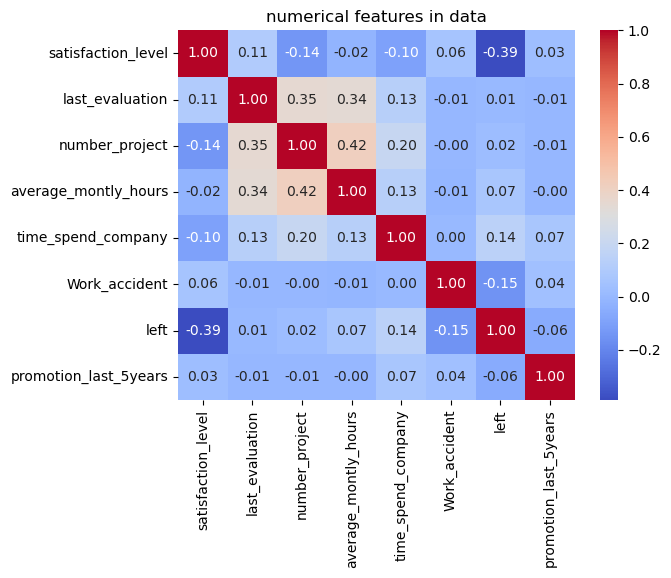

In [91]:
sns.heatmap(corr_matrix,annot=True,cmap="coolwarm", fmt=".2f")
plt.title("numerical features in data")
plt.show()

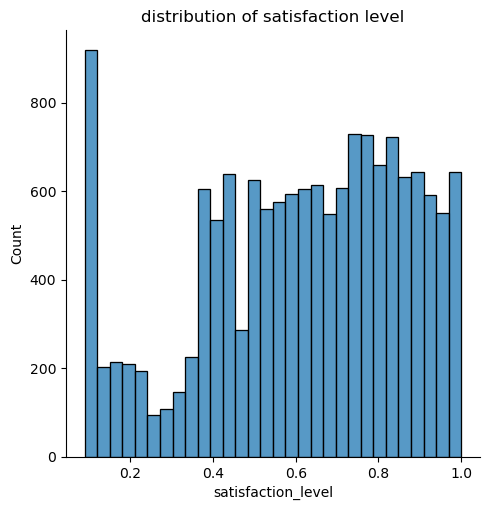

In [92]:
sns.displot(data=df, x="satisfaction_level",kind="hist")
plt.title("distribution of satisfaction level")
plt.show()

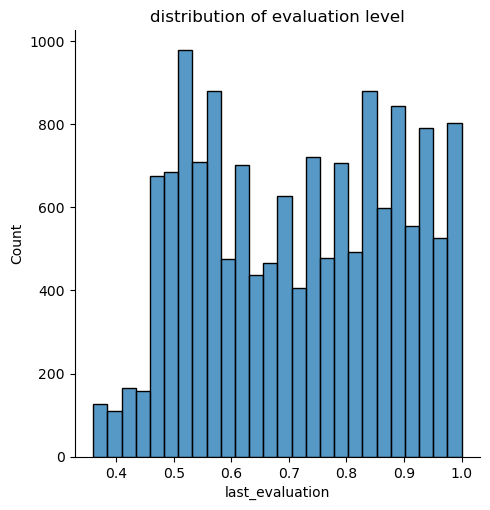

In [93]:
sns.displot(data=df, x="last_evaluation",kind="hist", fill=True)
plt.title("distribution of evaluation level")
plt.show()

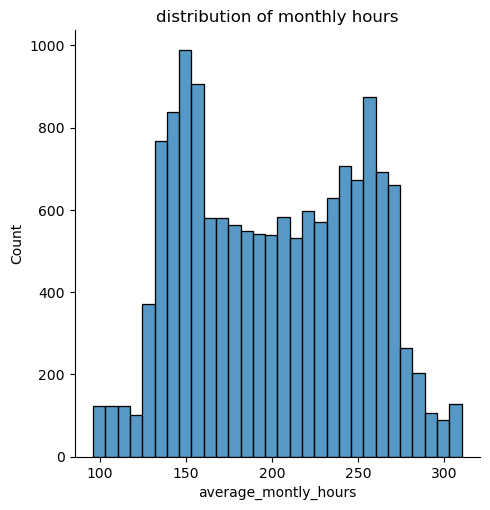

In [94]:
sns.displot(data=df, x="average_montly_hours",kind="hist", fill=True)
plt.title("distribution of monthly hours")
plt.show()

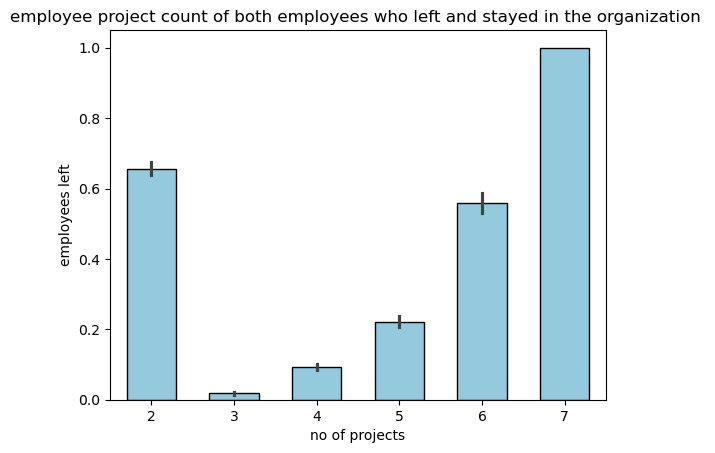

In [95]:
sns.barplot(data=df, x="number_project",y="left", color="skyblue", edgecolor="black", width=0.6)
plt.title("employee project count of both employees who left and stayed in the organization ")
plt.xlabel("no of projects")
plt.ylabel("employees left")
plt.show()

## I can draw an inference from it that the employees who have got 2 6 or 7 projects have left the company whereas the ones who have got {3,4,5} projects they have stayed in the company

## Clustering class algorithm

In [96]:
df_clustering=df.loc[df['left']==1,['satisfaction_level','last_evaluation']]

In [97]:
df_clustering.head(5)

,satisfaction_level,last_evaluation
0,0.38,0.53
1,0.80,0.86
2,0.11,0.88
3,0.72,0.87
4,0.37,0.52


In [98]:
!pip install scikit-learn

In [99]:
from sklearn.cluster import KMeans
k_means=KMeans(n_clusters=3)

In [100]:
y_means=k_means.fit_predict(df_clustering)
x=df_clustering.values

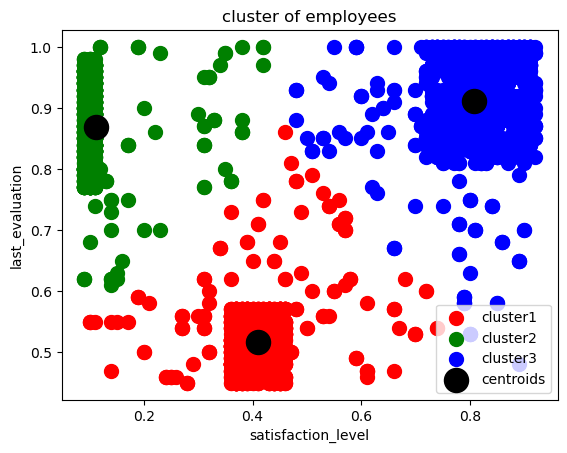

In [101]:
plt.scatter(x[y_means == 0,0], x[y_means == 0,1], s=100, c='red', label='cluster1')
plt.scatter(x[y_means == 1,0], x[y_means == 1,1], s=100, c='green', label='cluster2')
plt.scatter(x[y_means == 2,0], x[y_means == 2,1], s=100, c='blue', label='cluster3')
plt.scatter(k_means.cluster_centers_[:,0], k_means.cluster_centers_[:,1], s=300, c='black', label='centroids')
plt.title('cluster of employees')
plt.xlabel('satisfaction_level')
plt.ylabel('last_evaluation')
plt.legend()
plt.show()

## THey are forming literally three groups there are some outliers in the above plot but they can also be seprated easily


##SMOTE TECHNIQUE

In [102]:
df_categorical=df.iloc[:,[8,9]]
df_numerical=df.iloc[:,0:8]

In [103]:
encoded=pd.get_dummies(df_categorical,prefix="col", dtype=int)

In [104]:
encoded.head(5)

,col_IT,col_RandD,col_accounting,col_hr,col_management,col_marketing,col_product_mng,col_sales,col_support,col_technical,col_high,col_low,col_medium
0,0,0,0,0,0,0,0,1,0,0,0,1,0
1,0,0,0,0,0,0,0,1,0,0,0,0,1
2,0,0,0,0,0,0,0,1,0,0,0,0,1
3,0,0,0,0,0,0,0,1,0,0,0,1,0
4,0,0,0,0,0,0,0,1,0,0,0,1,0


In [105]:
df_combined = pd.concat([df_numerical, encoded], axis=1)

In [106]:
df_combined.head(5)

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,col_IT,col_RandD,...,col_hr,col_management,col_marketing,col_product_mng,col_sales,col_support,col_technical,col_high,col_low,col_medium
0,0.38,0.53,2,157,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
1,0.80,0.86,5,262,6,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
2,0.11,0.88,7,272,4,0,1,0,0,0,...,0,0,0,0,1,0,0,0,0,1
3,0.72,0.87,5,223,5,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0
4,0.37,0.52,2,159,3,0,1,0,0,0,...,0,0,0,0,1,0,0,0,1,0


In [107]:
from sklearn.model_selection import train_test_split

In [108]:
X=df_numerical.drop(columns=["left"]).values
y=df_combined["left"].values

In [109]:
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, stratify=y, random_state=123)

In [110]:
from sklearn.preprocessing import StandardScaler

In [111]:
Sc= StandardScaler()

In [112]:
X_train_scaled= Sc.fit_transform(X_train)

In [113]:
X_test_scaled= Sc.transform(X_test)

In [114]:
!pip install imbalanced-learn

In [115]:
from imblearn.over_sampling import SMOTE

In [116]:
smote=SMOTE(random_state=123)

In [117]:
X_train_balanced, y_train_balanced= smote.fit_resample(X_train_scaled,y_train)

In [143]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.pipeline import make_pipeline

In [146]:
pipeline=make_pipeline(LogisticRegression(max_iter=100, random_state=123))
cv_strategy=StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

In [120]:
y_predict= cross_val_predict(pipeline, X_train_balanced, y_train_balanced, cv=cv_strategy)

In [121]:
report_dict= classification_report(y_train_balanced, y_predict, output_dict=True)
report_df = pd.DataFrame(report_dict).iloc[:-1, :].T

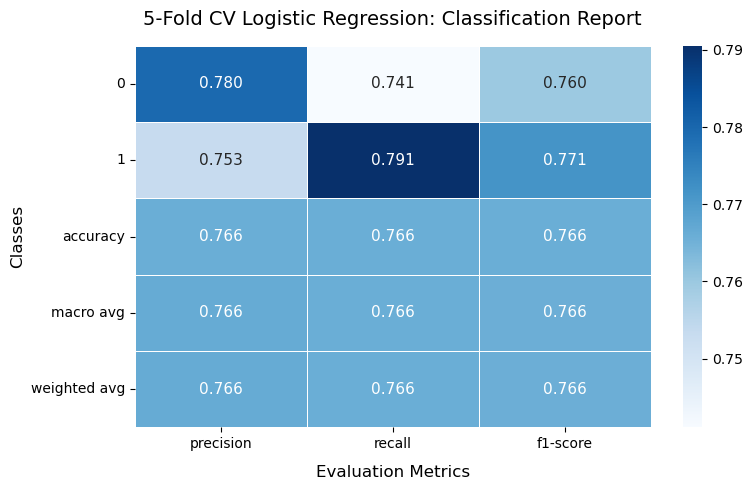

In [122]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    report_df, 
    annot=True, 
    cmap="Blues", 
    fmt=".3f", 
    cbar=True,
    linewidths=0.5,
    annot_kws={"size": 11}
)

plt.title("5-Fold CV Logistic Regression: Classification Report", fontsize=14, pad=15)
plt.xlabel("Evaluation Metrics", fontsize=12, labelpad=10)
plt.ylabel("Classes", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [147]:
from sklearn.ensemble import RandomForestClassifier
rf= make_pipeline(RandomForestClassifier(n_estimators=100, max_depth=None, random_state=123))
cv_strata=StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

In [124]:
y_pre= cross_val_predict(rf, X_train_balanced, y_train_balanced, cv=cv_strata)

In [125]:
report_d= classification_report(y_train_balanced, y_pre, output_dict=True)
report_f= pd.DataFrame(report_d).iloc[:-1, :].T

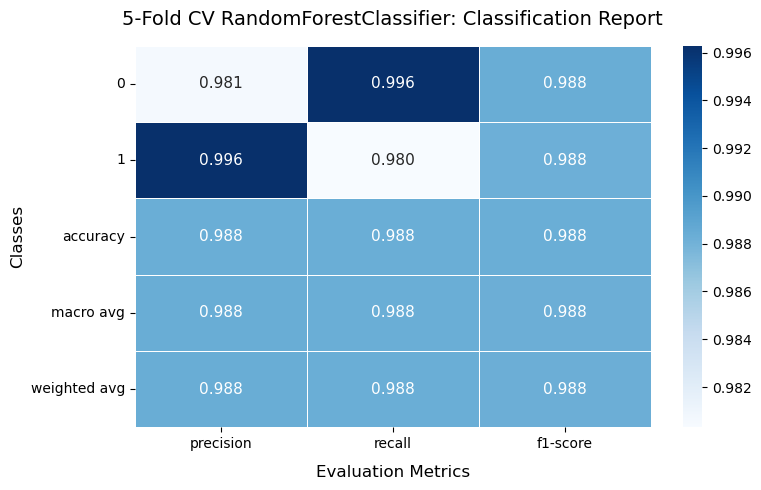

In [126]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    report_f, 
    annot=True, 
    cmap="Blues", 
    fmt=".3f", 
    cbar=True,
    linewidths=0.5,
    annot_kws={"size": 11}
)

plt.title("5-Fold CV RandomForestClassifier: Classification Report", fontsize=14, pad=15)
plt.xlabel("Evaluation Metrics", fontsize=12, labelpad=10)
plt.ylabel("Classes", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [148]:
from sklearn.ensemble import GradientBoostingClassifier
r= make_pipeline(GradientBoostingClassifier(n_estimators=100, max_depth=None, random_state=123))
cv_s=StratifiedKFold(n_splits=5, shuffle=True, random_state=123)

In [128]:
y_pe= cross_val_predict(r, X_train_balanced, y_train_balanced, cv=cv_s)

In [129]:
report_n= classification_report(y_train_balanced, y_pe, output_dict=True)
report_g= pd.DataFrame(report_n).iloc[:-1, :].T

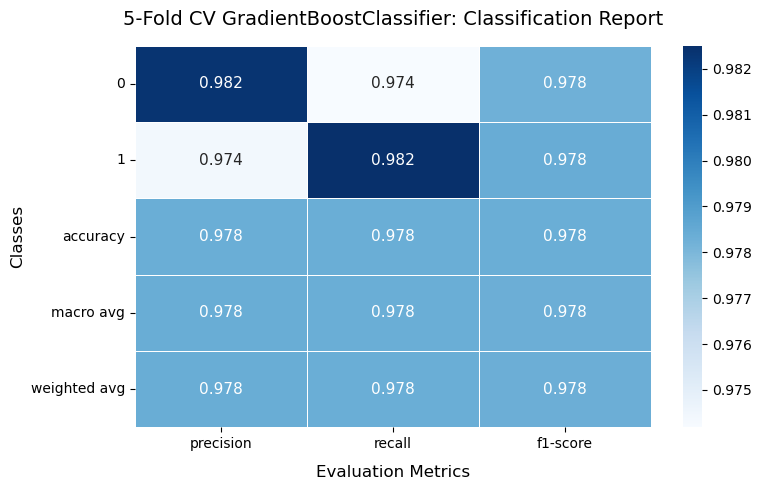

In [130]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    report_g, 
    annot=True, 
    cmap="Blues", 
    fmt=".3f", 
    cbar=True,
    linewidths=0.5,
    annot_kws={"size": 11}
)

plt.title("5-Fold CV GradientBoostClassifier: Classification Report", fontsize=14, pad=15)
plt.xlabel("Evaluation Metrics", fontsize=12, labelpad=10)
plt.ylabel("Classes", fontsize=12)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [173]:
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay, confusion_matrix

##ROC for logisticregression

In [174]:
pipeline.fit(X_train_balanced, y_train_balanced)
y_logistic= pipeline.predict(X_test)

In [175]:
cmf= confusion_matrix(y_test, y_logistic)
test_auc = roc_auc_score(y_test, y_logistic)
fpr, tpr, thresholds = roc_curve(y_test, y_logistic)
print(cmf)
print(test_auc)

[[   0 2286]
 [   0  714]]
0.5


In [177]:
rf.fit(X_train_balanced, y_train_balanced)
y_randomforest= rf.predict(X_test)

In [182]:
cm= confusion_matrix(y_test, y_randomforest)
auc = roc_auc_score(y_test, y_randomforest)
fp, tp, threshold = roc_curve(y_test, y_randomforest)
print(cm)
print(auc)

[[1593  693]
 [ 697   17]]
0.36032995875515555


In [179]:
r.fit(X_train_balanced, y_train_balanced)
y_gradientboosting= r.predict(X_test)

In [183]:
c= confusion_matrix(y_test, y_gradientboosting)
au = roc_auc_score(y_test, y_gradientboosting)
f, t, threshol = roc_curve(y_test, y_gradientboosting)
print(c)
print(au)

[[1378  908]
 [ 420  294]]
0.5072821779630486


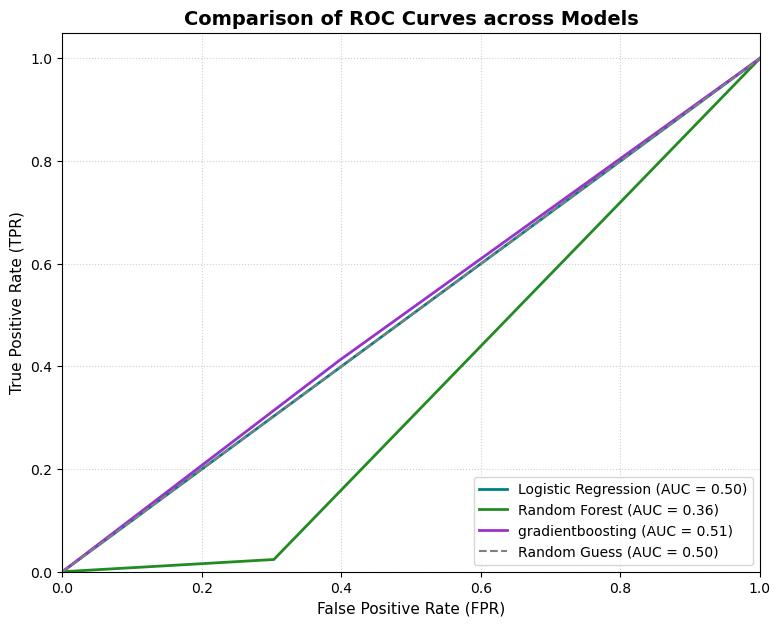

In [184]:
plt.figure(figsize=(9, 7))

# Plot each model curve with a unique color and label
plt.plot(fpr, tpr, color='teal', lw=2, label=f'Logistic Regression (AUC = {test_auc:.2f})')
plt.plot(fp, tp, color='forestgreen', lw=2, label=f'Random Forest (AUC = {auc:.2f})')
plt.plot(f, t, color='darkorchid', lw=2, label=f'gradientboosting (AUC = {au:.2f})')

# Plot the random guess reference line
plt.plot([0, 1], [0, 1], color='gray', lw=1.5, linestyle='--', label='Random Guess (AUC = 0.50)')

# Formatting details
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR)', fontsize=11)
plt.title('Comparison of ROC Curves across Models', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)

plt.show()

## We should be using recall because of the cost of a falsenegative because when an employee left the company but we predict it wrong then there must be cost for recruitment, onboarding and lost productivity

## BEST MODEL IS GRADIENT BOOSTING

In [185]:
probablity_leaving= r.predict_proba(X_test)
turnover= probablity_leaving[:, 1]

In [186]:
print(turnover)

[9.64165701e-01 2.19017313e-05 2.19017313e-05 ... 3.53586936e-02
 9.99978098e-01 2.19017313e-05]


In [189]:
turnover_predictions = pd.DataFrame({
    'Employee_ID': range(len(X_test)),  # Maps back to unique employee identifiers
    'Turnover_Probability': turnover
})

In [191]:
# Define continuous logic mapping thresholds to risk zones
conditions = [
    (turnover_predictions['Turnover_Probability'] < 0.20),
    (turnover_predictions['Turnover_Probability'] >= 0.20) & (turnover_predictions['Turnover_Probability'] <= 0.60),
    (turnover_predictions['Turnover_Probability'] > 0.60) & (turnover_predictions['Turnover_Probability'] <= 0.90),
    (turnover_predictions['Turnover_Probability'] > 0.90)
]

zones = ['Safe Zone (Green)', 'Low-Risk Zone (Yellow)', 'Medium-Risk Zone (Orange)', 'High-Risk Zone (Red)']

# Create the categorization column
turnover_predictions['Risk_Zone'] = np.select(conditions, zones, default='Unknown')

# Display sample distribution of your workforce
print(turnover_predictions['Risk_Zone'].value_counts())


Risk_Zone
Safe Zone (Green)       1798
High-Risk Zone (Red)    1202
Name: count, dtype: int64


## THE END